# Creation of figures relating to CeLLaTe data stats

Beginning with entity annotations per paper annotated, sourced from Google sheet at https://docs.google.com/spreadsheets/d/1fQpxvOkTRyt0fjywfrj9yeig3DbzNvf8ZrnV1GEGyKg/edit?usp=sharing

In [3]:
# import sys
# !{sys.executable} -m ensurepip --upgrade
# # !{sys.executable} -m pip install bokeh
# !{sys.executable} -m pip install matplotlib
# !{sys.executable} -m pip install seaborn


In [4]:
from bokeh.io import output_notebook, show, export_svgs
from bokeh.plotting import figure
output_notebook()


Loading BokehJS ...

In [5]:
import pandas as pd

# Read-in paper stats file
in_file = pd.read_csv("/Users/withers/Downloads/CeLLaTe-Paper-Records - Paper-Stats.csv")
in_file = in_file.drop(['Unnamed: 9'], axis=1)
in_file = in_file[in_file["Paper Source"] != "CheMBL_V1"]
in_file.head()

,PMCID,Paper Source,Entities-Annotated,Total num sentences,Total Sentences with entities,Total Entity Count,Tissue Count,CellType Count,CellLine Count,Paper Source.1,% Sentences w. entities,% Tissue entities,% CellType entities,% CellLine entities,Sanity check
0,PMC12115102,CheMBL_V2,"Celltype, Tissue, Cellline",99.0,35.0,53.0,10.0,1.0,42.0,CheMBL,35.4,18.9,1.9,79.2,100.0
1,PMC12101583,CheMBL_V2,"Celltype, Tissue, Cellline",43.0,21.0,45.0,6.0,15.0,24.0,CheMBL,48.8,13.3,33.3,53.3,99.9
2,PMC12081701,CheMBL_V2,"Celltype, Cellline",101.0,8.0,9.0,0.0,1.0,8.0,CheMBL,7.9,0.0,11.1,88.9,100.0
3,PMC11075828,CheMBL_V2,"Celltype, Tissue, Cellline",78.0,12.0,14.0,1.0,9.0,4.0,CheMBL,15.4,7.1,64.3,28.6,100.0
4,PMC10442740,CheMBL_V2,"Celltype, Tissue, Cellline",38.0,19.0,34.0,10.0,17.0,7.0,CheMBL,50.0,29.4,50.0,20.6,100.0


In [6]:
chembl_df = in_file[in_file['Paper Source'] == 'CheMBL_V2']
sc_df = in_file[in_file['Paper Source'] == 'Single-Cell']
cf_df = in_file[in_file['Paper Source'] == 'CellFinder']


In [7]:
import os

# Point to Firefox application executable
os.environ["PATH"] += os.pathsep + "/Applications/Firefox.app/Contents/MacOS"

# Point to the Homebrew geckodriver
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
os.environ["PATH"] += os.pathsep + "/usr/local/bin"

In [8]:
from bokeh.models import ColumnDataSource, FactorRange
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap
from typing import List, TypeAlias, Optional

bokeh_plot : TypeAlias = figure

entity_types = ['Tissue', 'CellType', 'CellLine'] #Sub-groups of greater PMCID assignment

palette = ["#55a7e2", "#f3d476", "#33cc33bb"]  # Blue, Orange, Green
# start=1, end=2 tells it to only evaluate the entity_type part of your tuple!
color_mapper = factor_cmap(field_name='x', palette=palette, factors=entity_types, start=1, end=2)

def stacked_barplot(input_df: pd.DataFrame, width: Optional[int] = 800) -> bokeh_plot:

        pmcids = list(input_df['PMCID'])
        entity_types = ['Tissue', 'CellType', 'CellLine'] #Sub-groups of greater PMCID assignment
        df_source = input_df['Paper Source'].iloc[0]
        if df_source == 'CheMBL_V2':
                df_source = 'ChEMBL'
        elif df_source == 'Single-Cell':
                df_source = 'Single Cell'

        x = [(pmcid, entity_type) for pmcid in pmcids for entity_type in entity_types] #Labels

        counts = []
        for i in input_df.index:
                counts.append(input_df.loc[i, 'Tissue Count'])
                counts.append(input_df.loc[i, 'CellType Count'])
                counts.append(input_df.loc[i, 'CellLine Count'])

        source = ColumnDataSource(data=dict(x=x, counts=counts))

        p = figure(y_range=FactorRange(*x), height=800, width=width, title=f"Entity Counts for '{df_source}' sourced articles",
                toolbar_location=None, tools="")

        p.hbar(y='x', right='counts', height=0.9, source=source, fill_color=color_mapper, line_color=color_mapper)

        p.x_range.start = 0
        p.xgrid.grid_line_color = None
        p.ygrid.grid_line_color = None
        p.yaxis.group_label_orientation = 0

        return p

# p = stacked_barplot(input_df = cf_df)
# show(p)

In [9]:
from bokeh.layouts import row
from bokeh.io import show

p1 = stacked_barplot(input_df=chembl_df, width=400)
p2 = stacked_barplot(input_df=cf_df, width=400)
p3 = stacked_barplot(input_df=sc_df, width=400)

p1.output_backend = 'svg'
p2.output_backend = 'svg'
p3.output_backend = 'svg'

layout = row(p1, p2, p3)
# Layout saved to 3 separate files
saved = export_svgs(layout, filename="./plots/sources_layout.svg")
print(saved)
show(layout)


['./plots/sources_layout.svg', './plots/sources_layout_1.svg', './plots/sources_layout_2.svg']


/var/folders/p1/wmkmsf116z99tb_qh5snjmg40000gp/T/ipykernel_3094/2457077155.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chembl_df['Source'] = 'ChEMBL'
/var/folders/p1/wmkmsf116z99tb_qh5snjmg40000gp/T/ipykernel_3094/2457077155.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cf_df['Source'] = 'CellFinder'
/var/folders/p1/wmkmsf116z99tb_qh5snjmg40000gp/T/ipykernel_3094/2457077155.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

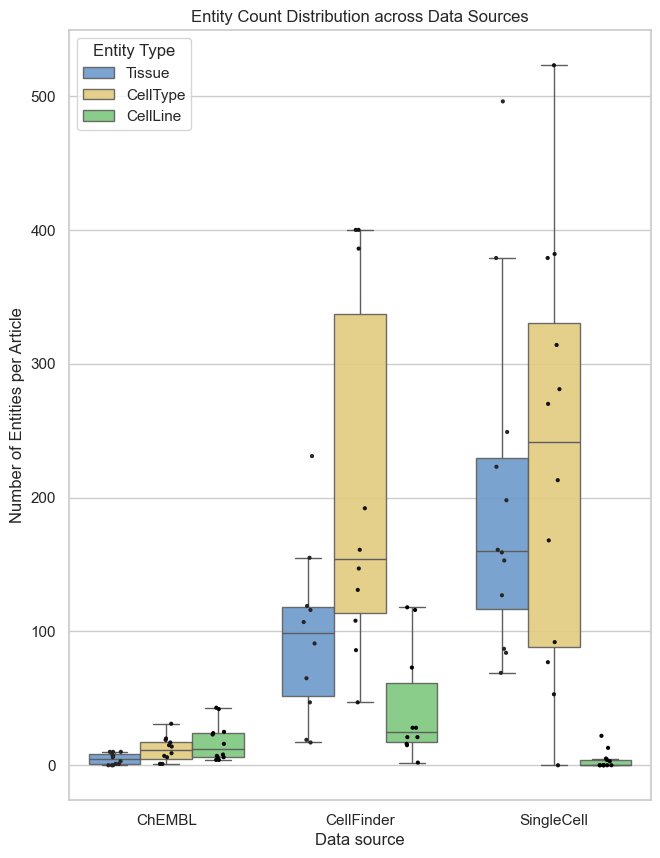

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cleaning source names 
chembl_df['Source'] = 'ChEMBL'
cf_df['Source'] = 'CellFinder'
sc_df['Source'] = 'SingleCell'

df_combined = pd.concat([chembl_df, cf_df, sc_df])

# Re-formatting 
df_melted = pd.melt(
    df_combined, 
    id_vars=['Source'],
    value_vars=['Tissue Count', 'CellType Count', 'CellLine Count'], 
    var_name='Entity Type', 
    value_name='Count'
)
# Drop 'Count' from entity names
df_melted['Entity Type'] = df_melted['Entity Type'].str.replace(' Count', '')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7.5, 10))

# Boxplot
ax = sns.boxplot(
    data=df_melted, 
    x="Source", 
    y="Count", 
    hue="Entity Type",
    palette=["#5e98d9", "#f2d26f", "#71d473"],
    showfliers=False, # Hides default outlier dots
    boxprops={'alpha': 0.9})

# Add strip plot
sns.stripplot(
    data=df_melted, 
    x="Source", 
    y="Count", 
    hue="Entity Type", 
    color="black",
    dodge=True, 
    jitter=True,
    size=3,
    ax=ax
)

# Clean up legend (drop duplicates)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title="Entity Type", loc="upper left")

plt.title("Entity Count Distribution across Data Sources")
plt.xlabel("Data source")
plt.ylabel("Number of Entities per Article")

plt.savefig("./plots/datasource_boxplot.svg", format="svg", bbox_inches="tight")
plt.savefig("./plots/datasource_boxplot.png", format="png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
def summary_counts(df: pd.DataFrame):

    cellline = df['CellLine Count'].sum()
    tissue = df['Tissue Count'].sum()
    celltype = df['CellType Count'].sum()

    return (tissue, celltype, cellline)

chembl_counts = summary_counts(chembl_df)
cf_counts = summary_counts(cf_df)
sc_counts = summary_counts(sc_df)

entity_types = ['Tissue', 'CellType', 'CellLine']
sources = ['ChEMBL', 'CellFinder', 'SingleCell']

x = [(source, entity_type) for source in sources for entity_type in entity_types] #Labels
counts = []
for i in [chembl_counts, cf_counts, sc_counts]:
    counts.append(i[0])
    counts.append(i[1])
    counts.append(i[2])

source = ColumnDataSource(data=dict(x=x, counts=counts))

p = figure(x_range=FactorRange(*x), height=300, width=550, title=f"Entity Counts",
           toolbar_location=None, tools="")

p.vbar(x='x', top='counts', width=0.9, source=source, fill_color=color_mapper, line_color=color_mapper)

p.y_range.start = 0
p.xgrid.grid_line_color = None
p.ygrid.grid_line_color = None
p.xaxis.major_label_orientation = 1

p.output_backend = 'svg'
export_svgs(p, filename="./plots/datasource_comp.svg")
show(p)


In [12]:
# Summary pie chart of counts per data source

from math import pi

import pandas as pd

from bokeh.io import export_png, export_svg
from bokeh.models import Legend, LegendItem
from bokeh.palettes import Category20c
from bokeh.plotting import figure, show
from bokeh.transform import cumsum

x = {
    'ChEMBL Tissue': chembl_counts[0],
    'ChEMBL CellType': chembl_counts[1],
    'ChEMBL CellLine': chembl_counts[2],
    'CellFinder Tissue': cf_counts[0],
    'CellFinder CellType': cf_counts[1],
    'CellFinder CellLine': cf_counts[2],
    'SingleCell Tissue': sc_counts[0],
    'SingleCell CellType': sc_counts[1],
    'SingleCell CellLine': sc_counts[2]
}

data = pd.Series(x).reset_index(name='value').rename(columns={'index': 'Source'})
data['Category'] = data['Source'].apply(lambda x: x.split(' ')[0]) # "ChEMBL"
data['SubCategory'] = data['Source'].apply(lambda x: x.split(' ')[1]) # "Tissue"

data['angle'] = data['value']/data['value'].sum() * 2*pi
data['color'] = ["#0f629e",
                 "#bbd8ee",
                 "#7fbde9",
                 "#f3bf76",
                 "#f9be0dae",
                 "#f99e71",
                 "#ca97ddb9",
                 "#e9b6ecee",
                 "#c694c8f0"]

p = figure(height=350, title="Entity Type representation per Data Source", toolbar_location=None,
           tools="hover", tooltips="@Source: @value", x_range=(-0.5, 1.0))

r = p.wedge(x=0, y=1, radius=0.4,
        start_angle=cumsum('angle', include_zero=True), end_angle=cumsum('angle'),
        line_color="black", fill_color='color', source=data)

p.axis.axis_label = 'None'
p.axis.visible = False
p.grid.grid_line_color = None

grouped = []
category = None
for i, row in data.iterrows():
    # Loop to group slices by data source e.g. ChEMBL
    if row['Category'] != category:
        if category is not None:
            grouped.append(LegendItem(label=" ", renderers=[])) # Blank spacer
        # Add 'source' header
        grouped.append(LegendItem(label=f"── {row['Category']} ──", renderers=[]))
        category = row['Category']
    
    # Add the actual entity type item
    subcat = row['SubCategory']

    count = str(int(row['value']))
    label = f'{subcat}  ({count})'
    grouped.append(LegendItem(label=label, renderers=[r], index=i))
# Add to p
legend = Legend(items=grouped, location="center_right")
p.add_layout(legend)

show(p)
export_png(p, filename="./plots/datasource_pie.png")
export_svg(p, filename="./plots/datasource_pie.svg")

['./plots/datasource_pie.svg']

In [75]:
from math import cos, pi, sin

total_tissue = sum([chembl_counts[0], cf_counts[0], sc_counts[0]])
total_celltype = sum([chembl_counts[1], cf_counts[1], sc_counts[1]])
total_cellline = sum([chembl_counts[2], cf_counts[2], sc_counts[2]])

x = {
    'Tissue': total_tissue,
    'CellType': total_celltype,
    'CellLine': total_cellline
}

data = pd.Series(x).reset_index(name='value').rename(columns={'index': 'Source'})

data['angle'] = data['value']/data['value'].sum() * 2*pi
data['color'] = ["#0f629e",
                 "#bbd8ee",
                 "#7fbde9"]
labels = ["Tissue", "CellType", "CellLine"]


p = figure(height=350, title="Entity Type representation per Data Source", toolbar_location=None,
           tools="hover", tooltips="@Source: @value", x_range=(-0.5, 1.0))

r = p.wedge(x=0, y=1, radius=0.4,
        start_angle=cumsum('angle', include_zero=True), end_angle=cumsum('angle'),
        legend_field='Source',
        line_color="black", fill_color='color', source=data)

# Create the text output layer
data['label_text'] = data['value'].apply(lambda v: str(int(v)) if v > 0 else "")

# Gather midpoint of each pie slice
data['mid'] = data['angle'].cumsum() - (data['angle'] / 2.0)

# Place value text at midpoint angle
radius_text = 0.48
data['x'] = data['mid'].apply(lambda a: radius_text * cos(a))
data['y'] = data['mid'].apply(lambda a: radius_text * sin(a))

source = ColumnDataSource(data)
p.text(x='x', y='y', text='label_text',
       source=data, text_align='center',
       text_baseline='middle',
       text_font_size="10pt", text_color="#333333")

p.axis.axis_label = 'None'
p.axis.visible = False
p.grid.grid_line_color = None

show(p)

In [55]:
from bokeh.plotting import figure, show
from bokeh.transform import cumsum
from math import cos, pi, sin
import pandas as pd
from bokeh.layouts import row

def plot_pie(source_counts, source_name: str):
    x = {
        'Tissue': source_counts[0],
        'CellType': source_counts[1],
        'CellLine': source_counts[2]
    }
    data = pd.Series(x).reset_index(name='value').rename(columns={'index': 'Source'})
    data['angle'] = data['value'] / data['value'].sum() * 2 * pi
    data['color'] = ["#95c5e7", "#bbd8ee", "#025b9a"]

    # Gather midpoint of each pie slice
    data['mid_angle'] = data['angle'].cumsum() - (data['angle'] / 2.0)
    
    # Place value text at midpoint angle
    radius_text = 0.48
    data['text_x'] = data['mid_angle'].apply(lambda a: radius_text * cos(a))-0.001
    data['text_y'] = data['mid_angle'].apply(lambda a: radius_text * sin(a))-0.001
    
    # Create the text output layer
    data['label_text'] = data['value'].apply(lambda v: str(int(v)) if v > 0 else "")

    p = figure(height=350, width=300,
               title=f"Entity Counts - {source_name}",
               toolbar_location=None,
               x_range=(-0.6, 0.6), y_range=(-0.6, 0.6))

    p.wedge(x=0, y=0, radius=0.4,
            start_angle=cumsum('angle', include_zero=True),
            end_angle=cumsum('angle'),
            line_color="white", fill_color='color', source=data)

    p.text(x='text_x', y='text_y', text='label_text', source=data,
           text_align='center', text_baseline='middle',
           text_font_size="10pt", text_color="#333333")
    p.axis.visible = False
    p.grid.grid_line_color = None
    return p

def create_standalone_legend():
    p_leg = figure(height=350, width=150, toolbar_location=None, 
                   x_range=(0, 1), y_range=(0, 1))
    
    colors = ["#95c5e7", "#bbd8ee", "#025b9a"]
    labels = ["Tissue", "CellType", "CellLine"]
    
    for color, label in zip(colors, labels):
        p_leg.scatter(x=[-10], y=[-10], size=20, fill_color=color, line_color=color, legend_label=label)
        
    p_leg.legend.location = "center_left"
    p_leg.legend.label_text_font_size = "15pt"
    p_leg.legend.border_line_color = None
    
    # Hide the axes and outline of this dummy plot
    p_leg.axis.visible = False
    p_leg.grid.grid_line_color = None
    p_leg.outline_line_color = None
    return p_leg

# - - - - - - - - - - - - - - - -

p1 = plot_pie(source_counts=chembl_counts, source_name="ChEMBL")
export_png(p1, filename="./plots/pie.png")
p2 = plot_pie(source_counts=cf_counts, source_name="CellFinder")
export_png(p2, filename="./plots/pie_1.png")
p3 = plot_pie(source_counts=sc_counts, source_name="SingleCell")
export_png(p3, filename="./plots/pie_2.png")
legend_panel = create_standalone_legend()
export_png(legend_panel, filename="./plots/pie_3.png")

p1.output_backend = 'svg'
p2.output_backend = 'svg'
p3.output_backend = 'svg'
legend_panel.output_backend = 'svg'

# Put them all in a row layout
layout = row(p1, p2, p3, legend_panel)
saved = export_svgs(layout, filename="./plots/pies_layout.svg")
print(saved)
show(layout)


['./plots/pies_layout.svg', './plots/pies_layout_1.svg', './plots/pies_layout_2.svg', './plots/pies_layout_3.svg']


In [14]:
# Same as above ^ but stacked bars
colors = ["#5e98d9", "#f2d26f", "#71d473"]

data = {
    'sources' : sources,
    'Tissue'  : [chembl_counts[0], cf_counts[0], sc_counts[0]],
    'CellType': [chembl_counts[1], cf_counts[1], sc_counts[1]],
    'CellLine': [chembl_counts[2], cf_counts[2], sc_counts[2]]
}

source = ColumnDataSource(data=data)

p = figure(x_range=sources, height=400, width=500, title="Entity Counts by Source",
           toolbar_location=None, tools="")

renderers = p.vbar_stack(
    stackers=entity_types, 
    x='sources', 
    width=0.7, 
    color=colors, 
    source=source,
    legend_label=entity_types
)

# Clean up axes and grid
p.y_range.start = 0
p.xgrid.grid_line_color = None
p.ygrid.grid_line_color = None
p.outline_line_color = None

p.legend.location = "top_left"
p.legend.orientation = "horizontal"

p.output_backend = 'svg'
export_svgs(p, filename="./plots/datasource_stacked_comp.svg")
show(p)
